# Importing Libararies

In [269]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

import warnings
warnings.filterwarnings("ignore")

✅ Libraries imported successfully!


In [270]:
# Load & Read The Data 
df = pd.read_csv('census.csv')
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


# Data Exploration

In [271]:
print("Dataset Dimensions:", df.shape)
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Dataset Dimensions: (45222, 14)
Number of Rows: 45222
Number of Columns: 14


In [272]:
cols = df.columns.tolist()
print("Columns Names:", cols)

Columns Names: ['age', 'workclass', 'education_level', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [273]:
# Data Info (Data Type of Each column)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [274]:
# Statistical Summary 
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


**Notes on numerical columns:**
1. capital-gain&capital-loss: Skewed Distribution.
2. capital-gain max = 99999 --> Outlier

In [275]:
df.describe(include='O')

,workclass,education_level,marital-status,occupation,relationship,race,sex,native-country,income
count,45222,45222,45222,45222,45222,45222,45222,45222,45222
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
freq,33307,14783,21055,6020,18666,38903,30527,41292,34014


**Observations**
1. Income Distribution is Imbalanced (it has 34014 for <=50k in income).
2. Native Country Has High Cardinality (it has 41 unique countries).
3. Binary Categorical Features (e.g., sex, income).

In [276]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [277]:
# Categorical Features Values
for col in categorical_cols:
    print(df[col].value_counts())
    print('===========')

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64
education_level
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64
marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64
occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales          

In [278]:
#import os
#from ydata_profiling import ProfileReport

#os.makedirs("reports", exist_ok=True)

#profile = ProfileReport(df, title="Pandas Profiling Report")
#profile.to_file("reports/first-exploration.html")

#profile.to_notebook_iframe()

from pandas_profiling import ProfileReport

pr_rep = ProfileReport(df, title="Pandas Profiling Report")
pr_rep

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 62.26it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [279]:
d = df["income"].value_counts()
target = pd.DataFrame(d)
target

,count
income,
<=50K,34014
>50K,11208


In [280]:
num_above_50k = d['>50K']
num_below_eq_50k = d['<=50K']

print("Number of individuals with income >$50,000:", num_above_50k)
print("Number of individuals with income <=$50,000:", num_below_eq_50k)

Number of individuals with income >$50,000: 11208
Number of individuals with income <=$50,000: 34014


In [281]:
perc_above_50k = (num_above_50k/df.shape[0]) * 100
print("Percentage of individuals with income >$50,000: {:.2f}%".format(perc_above_50k))

Percentage of individuals with income >$50,000: 24.78%


# Visualizations

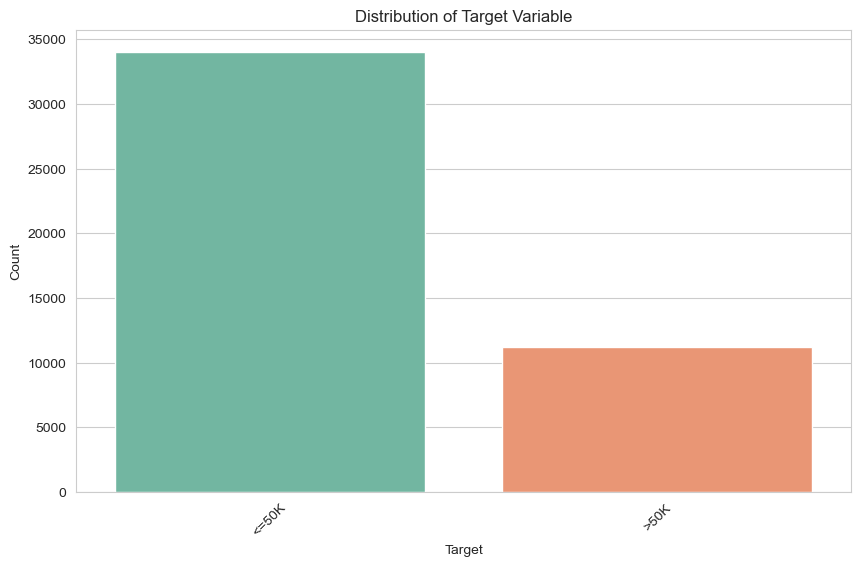

In [282]:
#colors = ['#FF9999','#66B3FF','#99FF99','#FFCC99','#C2C2F0','#FFB266']

sns.countplot(x='income', data=df, palette='Set2')
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

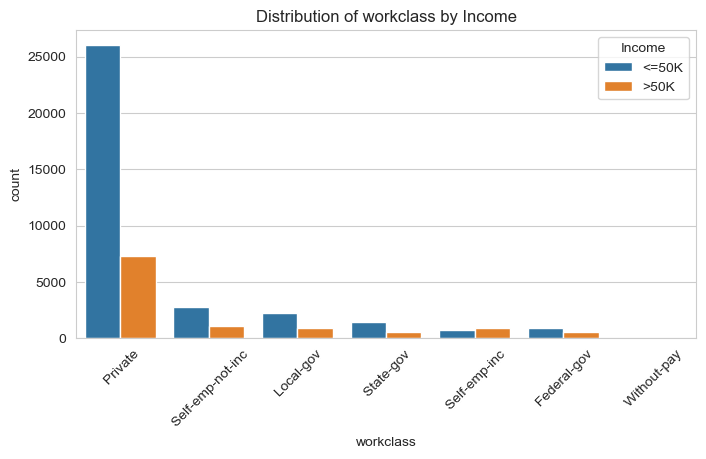

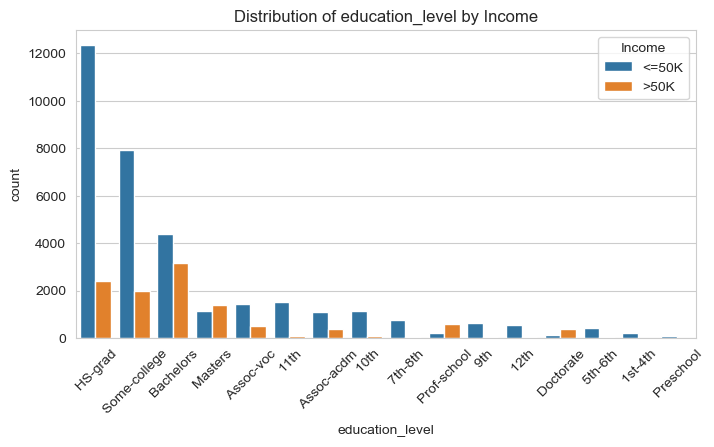

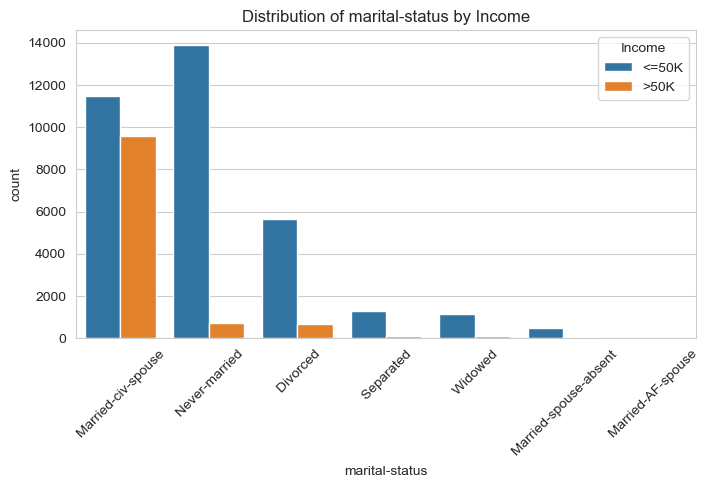

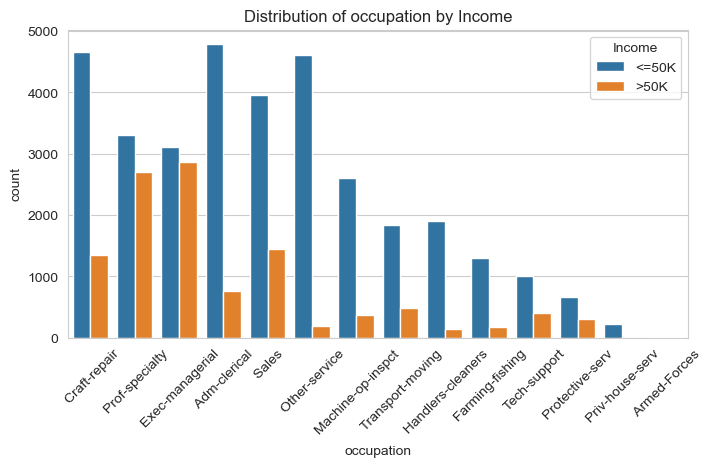

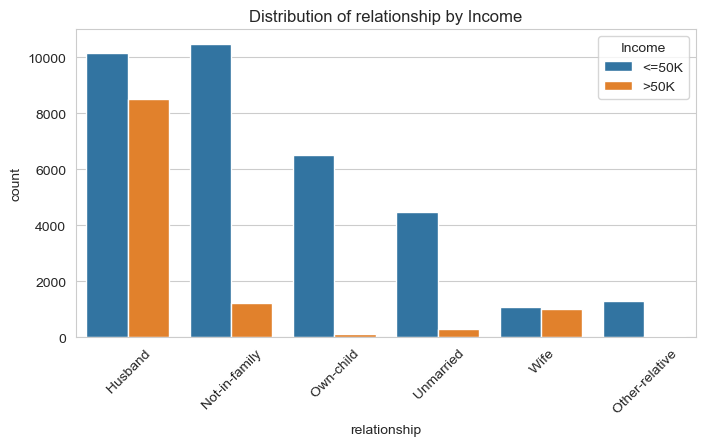

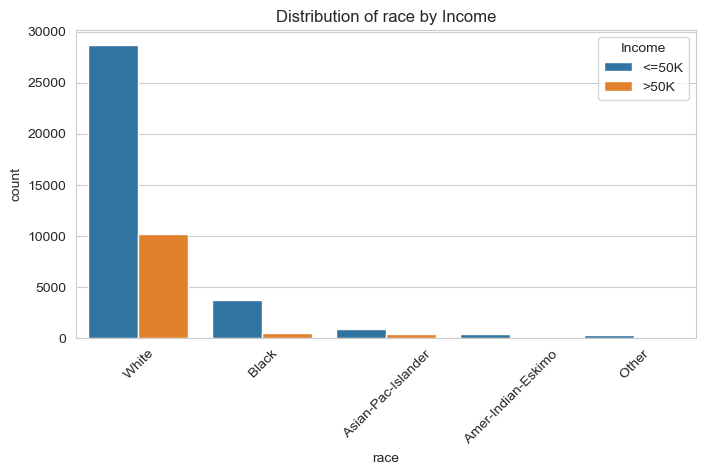

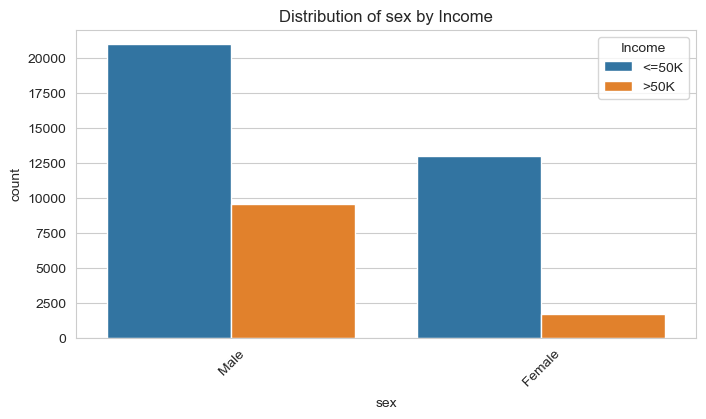

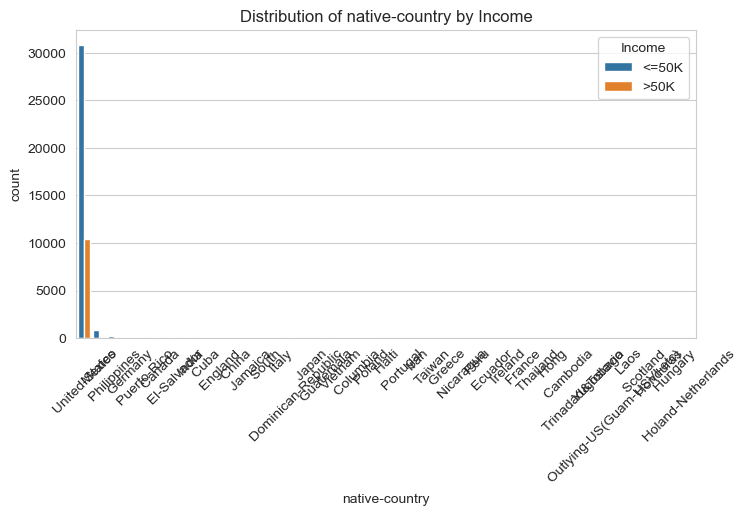

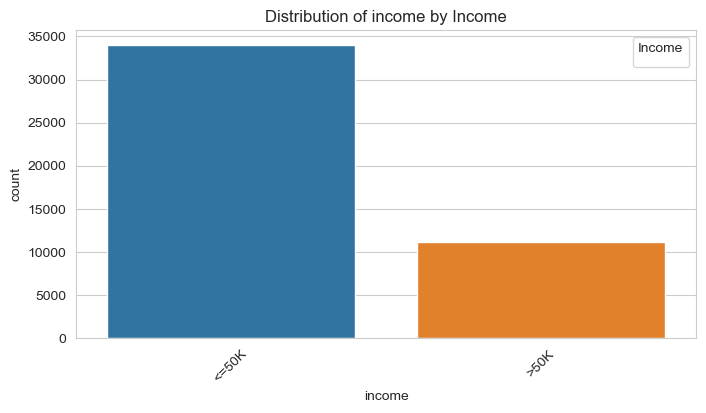

In [283]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, hue='income', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col} by Income')
    plt.xticks(rotation=45)
    plt.legend(title='Income')
    plt.show()

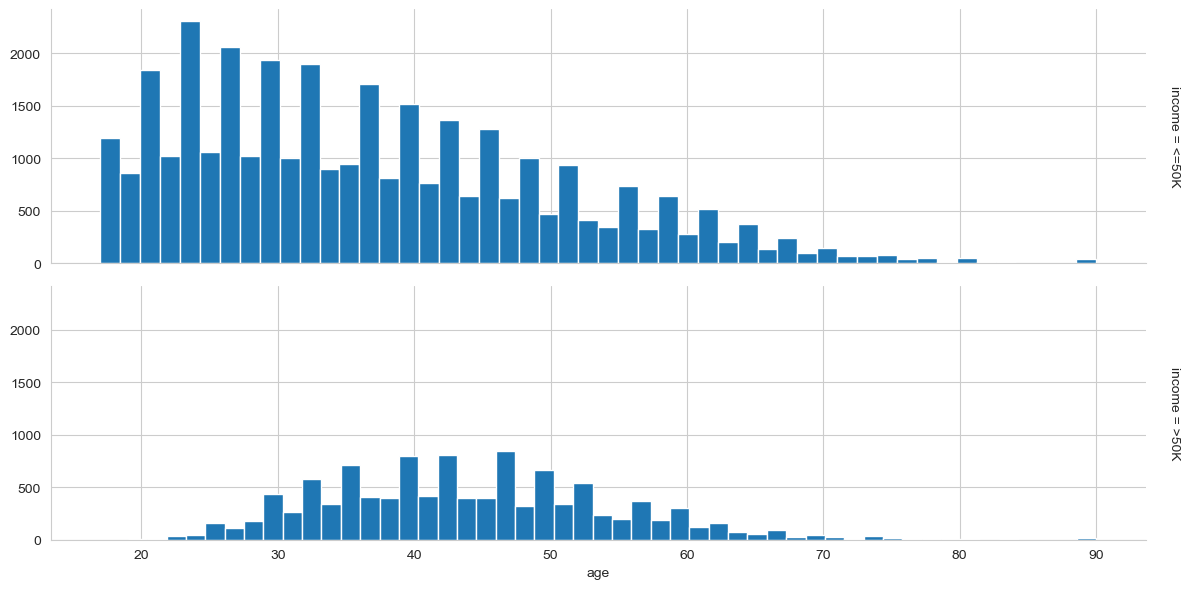

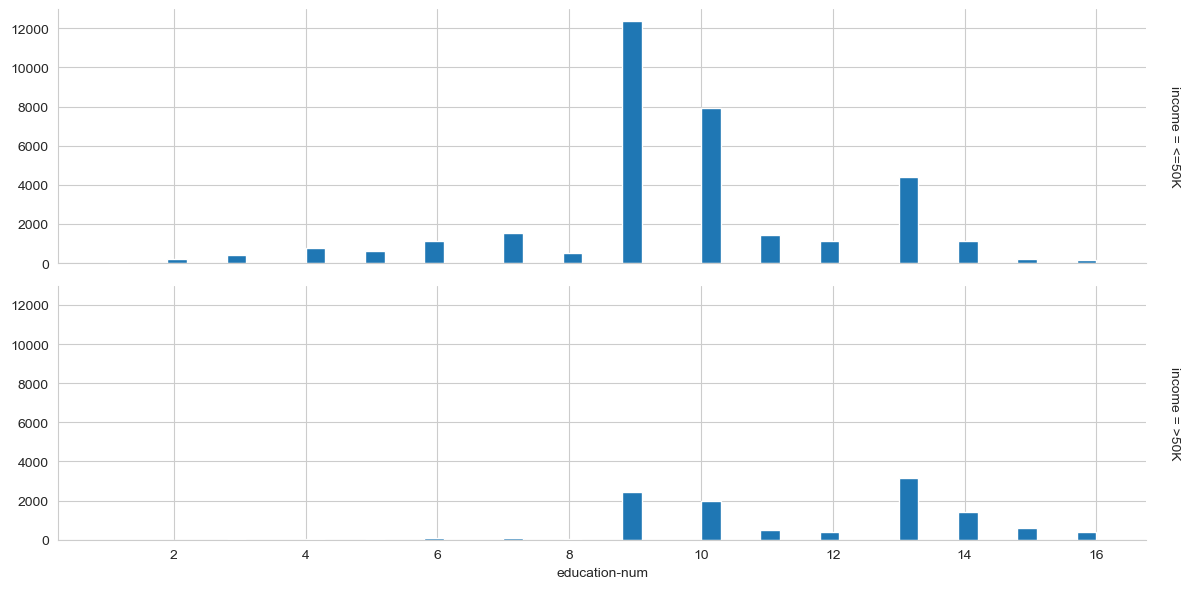

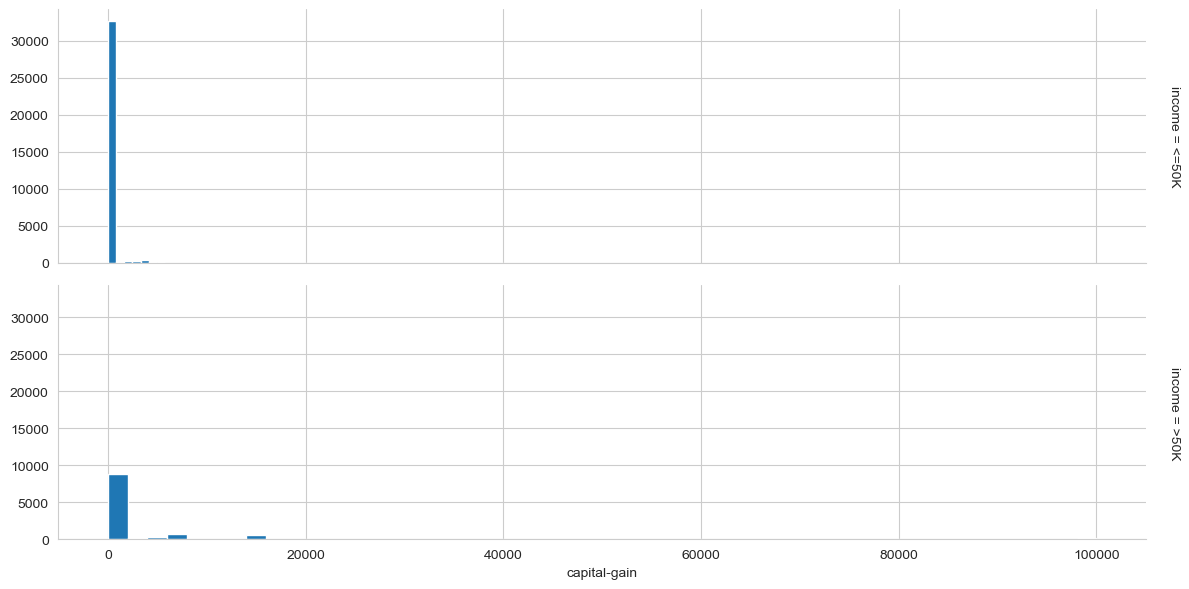

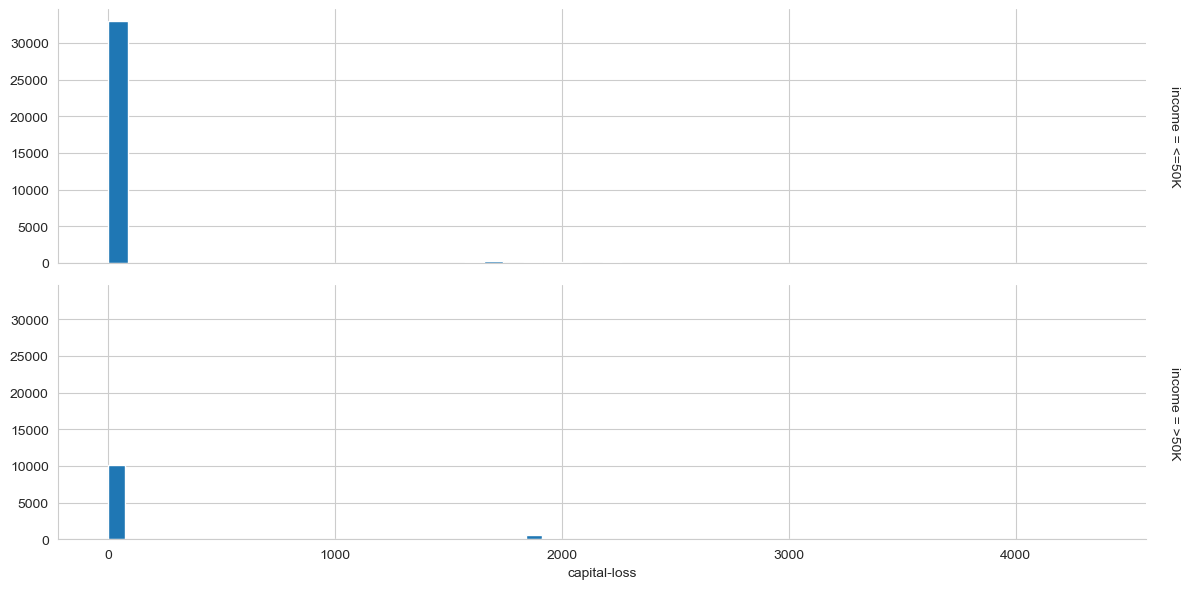

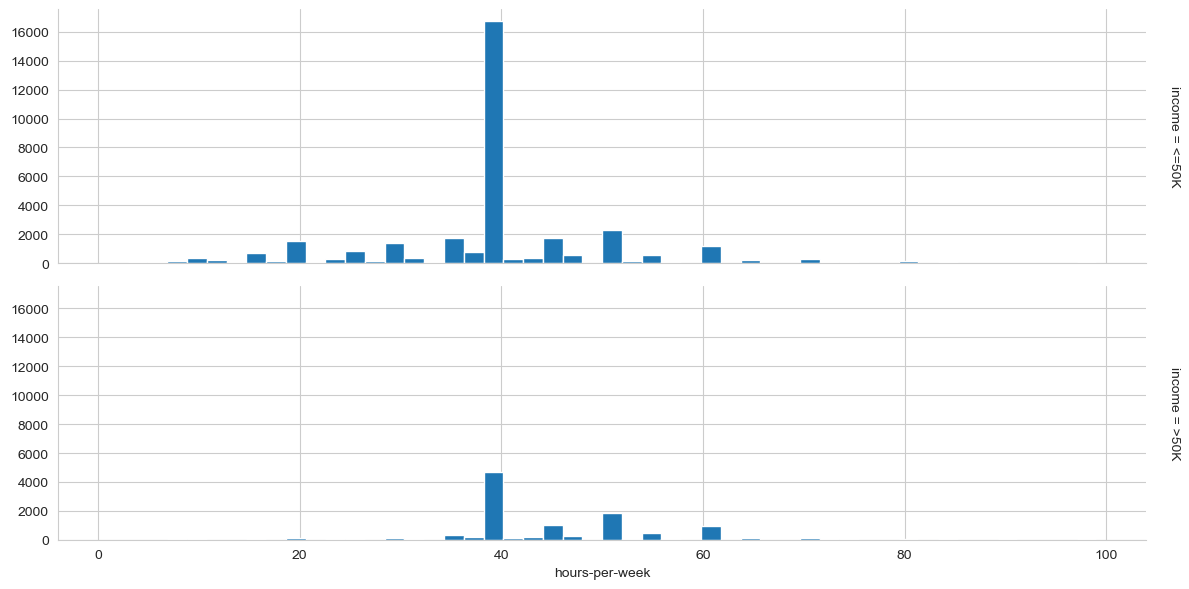

In [284]:
# Distribution of numerical features
for col in numerical_cols:
    g = sns.FacetGrid(df, row='income', margin_titles=True, aspect=4, height=3)
    g.map(plt.hist, col, bins=50) 
    plt.show()

In [285]:
# Check missing
print(f"Number of missing values: {df.isna().sum().sum()}")
print(f"Percentage of missing values:\n{df.isnull().mean() *100}")

Number of missing values: 0
Percentage of missing values:
age                0.0
workclass          0.0
education_level    0.0
education-num      0.0
marital-status     0.0
occupation         0.0
relationship       0.0
race               0.0
sex                0.0
capital-gain       0.0
capital-loss       0.0
hours-per-week     0.0
native-country     0.0
income             0.0
dtype: float64


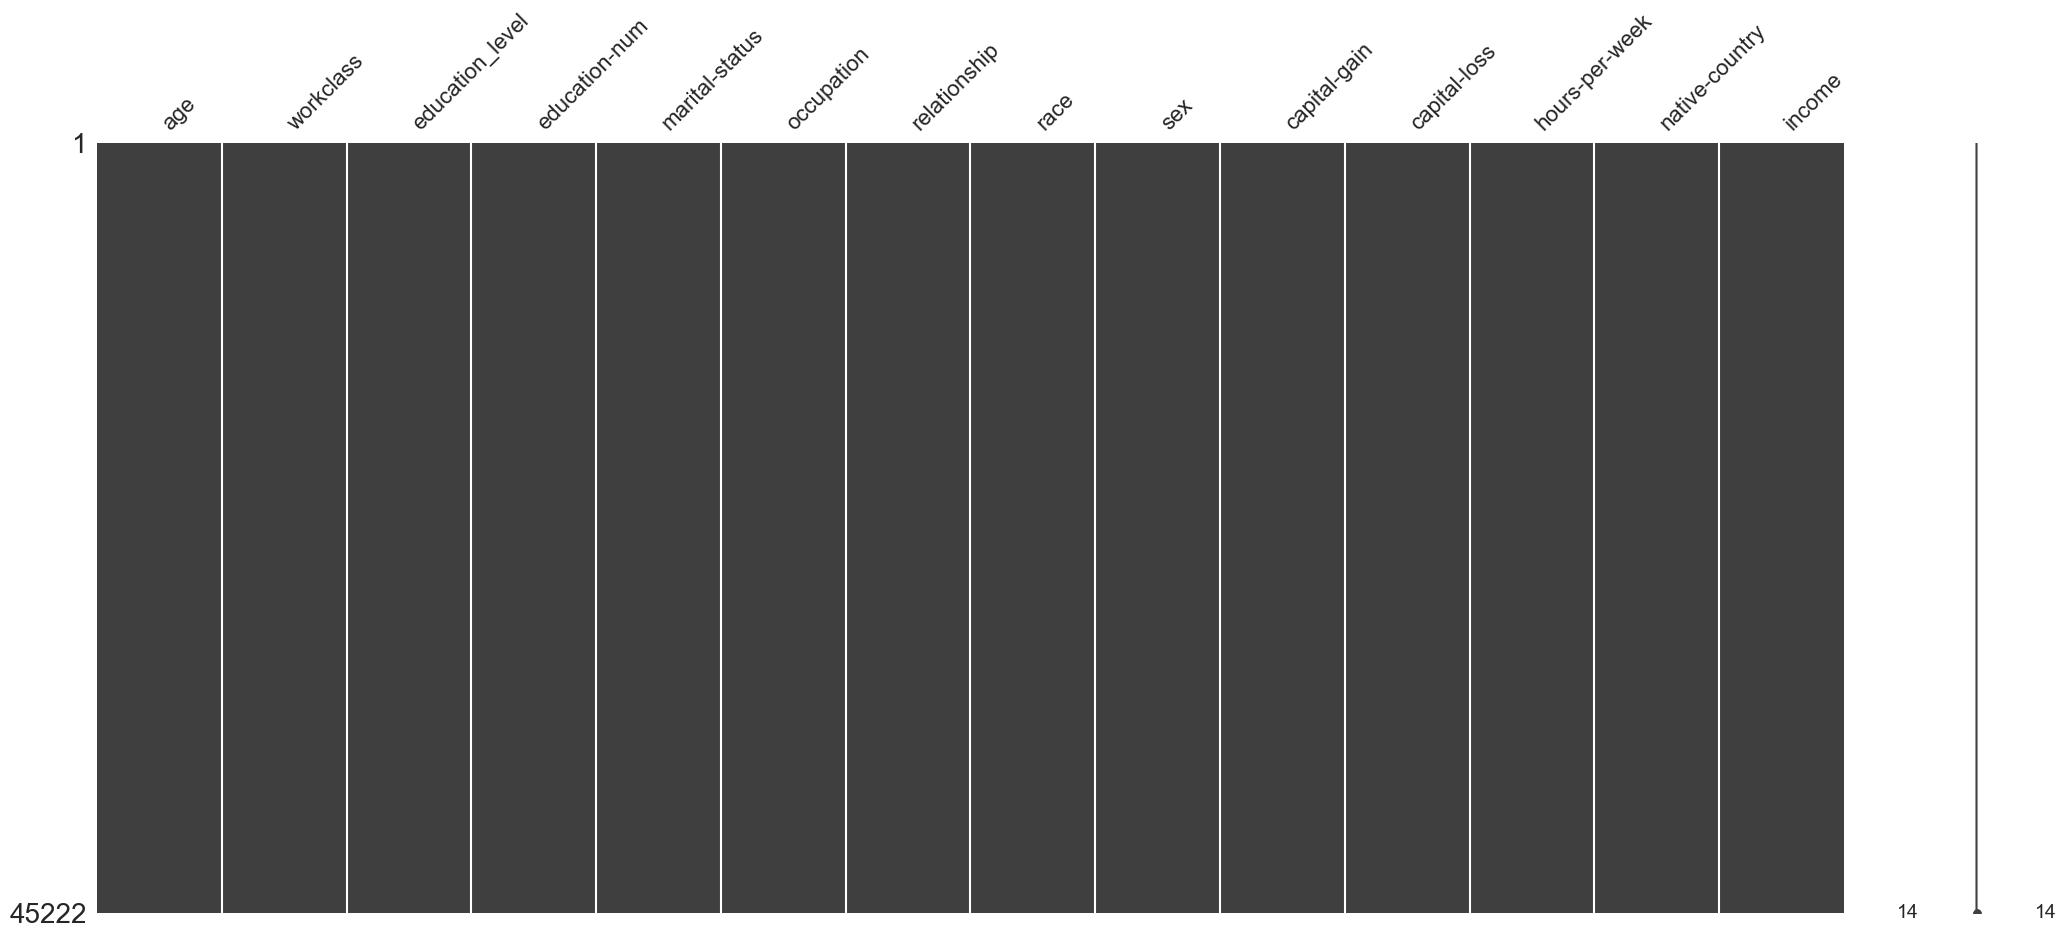

In [286]:
import missingno as msno
msno.matrix(df)
plt.show()

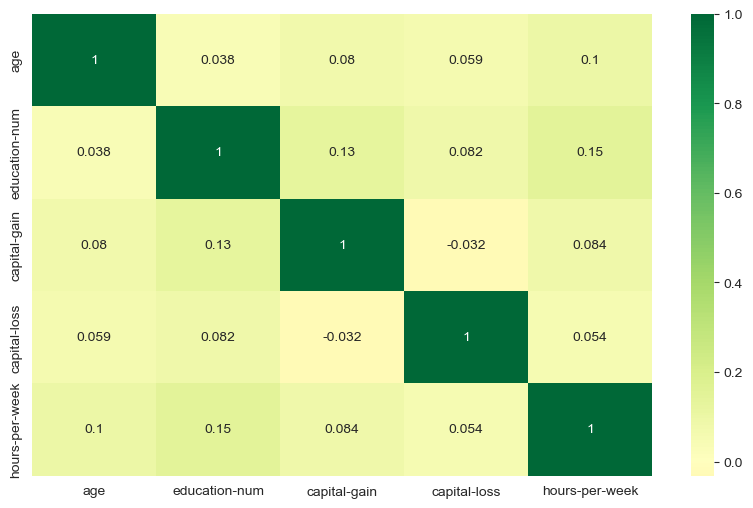

In [287]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', center=0)
plt.show()

**Outlier Detection - Boxplot**

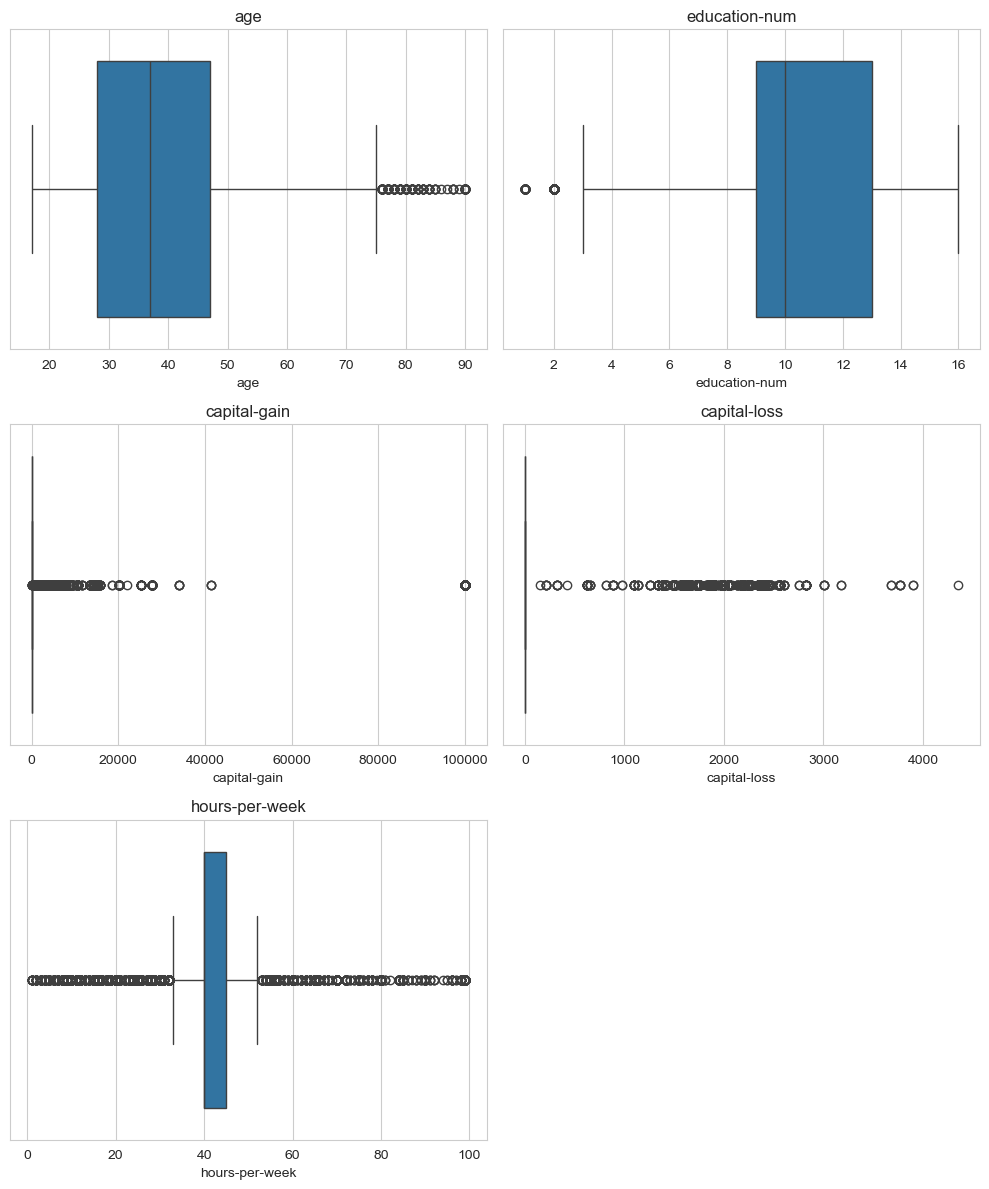

In [288]:
import math

# number of numeric features
n = len(numerical_cols)

# choose grid size dynamically
rows = math.ceil(n/2)  
cols = 2

plt.figure(figsize=(cols*5, rows*4))

for i, feature in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [289]:
def detect_outliers_iqr(series, lower_percentile=25, upper_percentile=75, factor=1.5):
    Q1 = np.nanpercentile(series, lower_percentile)
    Q3 = np.nanpercentile(series, upper_percentile)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, len(outliers), lower, upper

In [290]:
for feature in numerical_cols:
    outliers, count, _, _ = detect_outliers_iqr(df[feature])
    print(f'{feature} >> Outliers detected: {count}')

age >> Outliers detected: 269
education-num >> Outliers detected: 294
capital-gain >> Outliers detected: 3790
capital-loss >> Outliers detected: 2140
hours-per-week >> Outliers detected: 11899


- Preprocessing Plan:
  1. Applying log transformation on capital-gain-log & capital-loss-log.
  2. Applying capping on hours-per-week.
  3. Categorical Features encoding.
  4. Handle outliers in hours-per-week.

# Preprocessing & Feature Engineering

In [291]:
# Handle outliers

lower_cap = df['hours-per-week'].quantile(0.01)
upper_cap = df['hours-per-week'].quantile(0.99)
df['hours-per-week'] = df['hours-per-week'].clip(lower_cap, upper_cap)

In [294]:
# Apply log transformation
log_features = ['capital-gain', 'capital-loss']
log_transformer = FunctionTransformer(np.log1p)
df[log_features] = log_transformer.fit_transform(df[log_features])

In [295]:
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40.0,Cuba,<=50K


In [296]:
#df.drop(columns=['capital-gain','capital-loss'], inplace=True)

In [297]:
# Workclass grouping
df['workclass'] = df['workclass'].replace({
    'Federal-gov':'Gov', 'State-gov':'Gov',  'Local-gov':'Gov',
    'Self-emp-inc':'Self-emp', 
    'Self-emp-not-inc':'Self-emp',
    'Without-pay':'Other'
})

# Education ordinal encoding 
df['education_level'] = df['education_level'].map(
        {'Preschool':'level_1','1st-4th':'level_1','5th-6th':'level_1','7th-8th':'level_1',
         '9th':'level_1','10th':'level_1','11th':'level_1','12th':'level_1','HS-grad':'level_1',
        'Prof-school':'level_2','Assoc-acdm':'level_2','Assoc-voc':'level_2','Some-college':'level_2',
        'Bachelors':'level_3','Masters':'level_3','Doctorate':'level_3'})

# Occupation ordinal encoding
occupation_level_mapping={
    'Adm-clerical':'level_1', 'Machine-op-inspct':'level_1', 'Farming-fishing':'level_1',
    'Handlers-cleaners':'level_1', 'Other-service':'level_1', 'Priv-house-serv':'level_1',
    'Tech-support':'level_2', 'Sales':'level_2', 'Craft-repair':'level_2', 'Transport-moving':'level_2',
    'Exec-managerial':'level_3', 'Prof-specialty':'level_3', 'Armed-Forces':'level_3', 'Protective-serv':'level_3'}

df['occupation']= df['occupation'].map(occupation_level_mapping)

# Sex binary encoding
df['sex'] = df['sex'].str.strip().map({'Female':0, 'Male':1})

# New Feature: is_married
df['is_married'] = df['marital-status'].apply(lambda x: 1 if x=='Married-civ-spouse' else 0)

# Native-country grouping (US vs Other)
df['native-country'] = df['native-country'].apply(lambda x: 'US' if x=='United-States' else 'Other')

# One-hot encoding for categorical features
# We keep 'education_level' and 'occupation_level' as ordinal, so no need to one-hot them
df = pd.get_dummies(df, columns=['education_level','occupation','workclass', 'relationship', 'race', 'native-country'], dtype = int, drop_first=True)

# Target Encoding
df['income'] = df['income'].map({'<=50K':0, '>50K':1})

# Drop unused columns
df.drop(columns=['marital-status'], inplace=True)

In [298]:
df.isna().sum()

age                             0
education-num                   0
sex                             0
capital-gain                    0
capital-loss                    0
hours-per-week                  0
income                          0
is_married                      0
workclass_ Local-gov            0
workclass_ Private              0
workclass_ Self-emp-inc         0
workclass_ Self-emp-not-inc     0
workclass_ State-gov            0
workclass_ Without-pay          0
relationship_ Not-in-family     0
relationship_ Other-relative    0
relationship_ Own-child         0
relationship_ Unmarried         0
relationship_ Wife              0
race_ Asian-Pac-Islander        0
race_ Black                     0
race_ Other                     0
race_ White                     0
dtype: int64

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           45222 non-null  int64  
 1   education-num                 45222 non-null  float64
 2   sex                           45222 non-null  int64  
 3   capital-gain                  45222 non-null  float64
 4   capital-loss                  45222 non-null  float64
 5   hours-per-week                45222 non-null  float64
 6   income                        45222 non-null  int64  
 7   is_married                    45222 non-null  int64  
 8   workclass_ Local-gov          45222 non-null  int32  
 9   workclass_ Private            45222 non-null  int32  
 10  workclass_ Self-emp-inc       45222 non-null  int32  
 11  workclass_ Self-emp-not-inc   45222 non-null  int32  
 12  workclass_ State-gov          45222 non-null  int32  
 13  w

In [300]:
df.head(10)

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,is_married,workclass_ Local-gov,workclass_ Private,...,workclass_ Without-pay,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
0,39,13.0,1,7.684784,0.0,40.0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13.0,1,0.000000,0.0,13.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9.0,1,0.000000,0.0,40.0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
3,53,7.0,1,0.000000,0.0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13.0,0,0.000000,0.0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
5,37,14.0,0,0.000000,0.0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
6,49,5.0,0,0.000000,0.0,16.0,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0
7,52,9.0,1,0.000000,0.0,45.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,31,14.0,0,9.552866,0.0,50.0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,1
9,42,13.0,1,8.552367,0.0,40.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [301]:
df.describe()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,is_married,workclass_ Local-gov,workclass_ Private,...,workclass_ Without-pay,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.0,45222.000000,45222.000000,...,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,0.675048,0.740759,0.355489,40.895051,0.247844,0.0,0.068551,0.736522,...,0.000464,0.258768,0.029831,0.146522,0.105878,0.046239,0.028813,0.093494,0.007806,0.860267
std,13.217870,2.552881,0.468362,2.466527,1.595914,11.565801,0.431766,0.0,0.252691,0.440524,...,0.021545,0.437963,0.170122,0.353632,0.307684,0.210004,0.167284,0.291127,0.088007,0.346714
min,17.000000,1.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,37.000000,10.000000,1.000000,0.000000,0.000000,40.000000,0.000000,0.0,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,47.000000,13.000000,1.000000,0.000000,0.000000,45.000000,0.000000,0.0,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,90.000000,16.000000,1.000000,11.512925,8.379539,80.000000,1.000000,0.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [304]:
# Now Splitting Data into train and test sets

X = df.drop(labels=['income'],axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [305]:
print("X Train Dimension: ", X_train.shape)
print("X Test Dimension: ", X_test.shape)
print("Y Train Dimension: ", y_train.shape)
print("Y Test  Dimension: ", y_test.shape)

X Train Dimension:  (33916, 22)
X Test Dimension:  (11306, 22)
Y Train Dimension:  (33916,)
Y Test  Dimension:  (11306,)


In [306]:
# Feature Scaling using standard scaler
numeric_features = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [307]:
X_train.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,is_married,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,...,workclass_ Without-pay,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
32838,0.487052,-1.217192,0,-0.300423,-0.224927,-0.512472,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
10770,2.304800,-0.436941,1,-0.300423,-0.224927,-1.461513,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2710,-0.346082,1.123560,1,-0.300423,-0.224927,-0.943854,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
33887,-0.043124,-0.046816,1,-0.300423,-0.224927,1.213058,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
28109,-0.800519,-0.436941,1,-0.300423,-0.224927,-0.081090,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
